In [1]:
import pandas as pd

from imblearn.under_sampling import RandomUnderSampler

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_unbalanced_combined.csv")

print(df.shape)

df.head()

(8764, 9)


,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Label,Source_File
0,0.611400,3276.089540,42.525376,26,0,26,255,NORMAL,normal_browsing.csv
1,4.773680,152.083928,2.304302,11,0,11,53248,ATTACK,NaN
2,4.469684,14165.653515,4.922048,22,0,22,16,NORMAL,normal_download.csv
3,0.007940,508339.417555,377.853878,3,0,3,255,NORMAL,normal_gaming.csv
4,4.888691,358081.099358,38.865206,190,128,62,512,ATTACK,NaN


In [3]:
print(df["Label"].value_counts())

print()

print(df["Label"].value_counts(normalize=True))

Label
NORMAL    6436
ATTACK    2328
Name: count, dtype: int64

Label
NORMAL    0.734368
ATTACK    0.265632
Name: proportion, dtype: float64


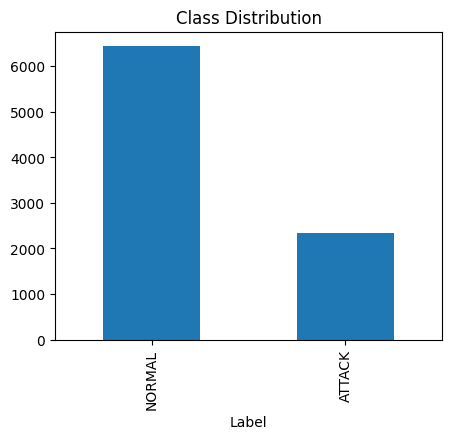

In [4]:
df["Label"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Class Distribution")
plt.show()

In [5]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [6]:
rus = RandomUnderSampler(
    random_state=42
)

X_balanced, y_balanced = rus.fit_resample(X, y)

In [7]:
balanced_df = X_balanced.copy()

balanced_df["Label"] = y_balanced

In [8]:
print(balanced_df.shape)

print()

print(balanced_df["Label"].value_counts())

(4656, 9)

Label
ATTACK    2328
NORMAL    2328
Name: count, dtype: int64


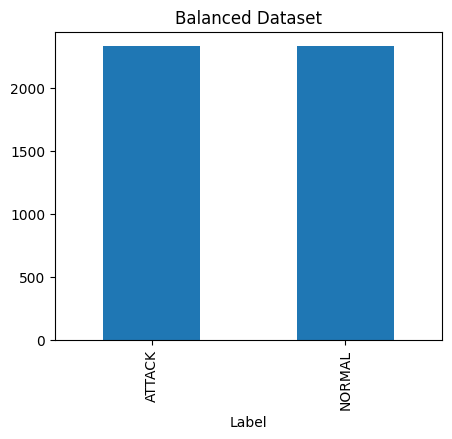

In [9]:
balanced_df["Label"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Balanced Dataset")

plt.show()

In [10]:
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [11]:
balanced_df.head()

,Flow Duration,Flow Bytes/s,Flow Packets/s,Total Fwd Packets,SYN Flag Count,ACK Flag Count,Init_Win_bytes_forward,Source_File,Label
0,4.043668,212.183578,3.214903,13,0,13,53248,NaN,ATTACK
1,0.113059,32558.140517,79.604256,9,1,9,65535,normal_streaming.csv,NORMAL
2,0.177058,5546.190842,50.830670,9,0,9,615,NaN,ATTACK
3,3.530323,78.179815,1.133041,4,0,4,53248,NaN,ATTACK
4,4.855382,299.049593,4.531054,22,0,22,53248,NaN,ATTACK


In [12]:
balanced_df.to_csv(
    "dataset_balanced.csv",
    index=False
)

In [13]:
balanced_df.columns

Index(['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Total Fwd Packets',
       'SYN Flag Count', 'ACK Flag Count', 'Init_Win_bytes_forward',
       'Source_File', 'Label'],
      dtype='object')

In [14]:
balanced_df = balanced_df.drop(
    columns=["Source_File"],
    errors="ignore"
)

In [15]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4656 entries, 0 to 4655
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Flow Duration           4656 non-null   float64
 1   Flow Bytes/s            4656 non-null   float64
 2   Flow Packets/s          4656 non-null   float64
 3   Total Fwd Packets       4656 non-null   int64  
 4   SYN Flag Count          4656 non-null   int64  
 5   ACK Flag Count          4656 non-null   int64  
 6   Init_Win_bytes_forward  4656 non-null   int64  
 7   Label                   4656 non-null   object 
dtypes: float64(3), int64(4), object(1)
memory usage: 291.1+ KB


In [16]:
balanced_df.to_csv(
    "dataset_balanced.csv",
    index=False
)